# 06. Disruption Index（革新性・断絶性）

**このノートブックで学ぶこと**：ある論文が「その分野の流れを大きく変えた（革新的・disruptive）」のか、「これまでの研究を順当に発展させた（発展的・developmental）」のかを、**引用のパターンだけ**から数値化する **Disruption Index (DI)** を計算します。

**直感**：ある論文 $f$ が本当に革新的なら、その後の研究者は「$f$ は引用するが、$f$ が土台にした古い文献（参考文献）はもう引用しない」ようになるはずです。$f$ が過去の流れを"上書き"したからです。逆に $f$ が既存研究の延長なら、後続論文は「$f$ も、$f$ の参考文献も両方」引用します。DIはこの違いを引用構造から測ります。

Disruption Index は Funk & Owen-Smith ([2017](https://pubsonline.informs.org/doi/abs/10.1287/mnsc.2015.2366)) が提唱し、Wu ら ([2019](https://www.nature.com/articles/s41586-019-0941-9)) が科学計量学に導入した指標です。Park ら ([2023](https://www.nature.com/articles/s41586-022-05543-x)) が「平均破壊スコアが数十年にわたり低下している」と報告し大きな議論を呼びました。一方で時系列比較には注意が必要との指摘もあります ([Leibel & Bornmann 2024](https://link.springer.com/article/10.1007/s11192-023-04873-5))。

このノートブックは ScisciJP `tutorial_jp` の **3-Disruptiveness** を踏襲し、**事前計算済みの引用エッジリスト**（`data/supplementary/`）を使ってDIを計算します。論文ごとにAPIを叩かず、ランダム抽出した論文サンプル全体に対してDI計算を試し、参考文献・被引用情報がそろってDIを定義できる論文だけを残します。この点だけ、01のバクテリオファージ・コーパスとは独立した自己完結ノートブックです。

## DIの定義
注目論文 $f$ とその参考文献群 $R$ について、後続論文（$f$ か $R$ を引用する論文）を次の3群に分けます:
- $N_i$: $f$ **のみ** を引用（$R$ は引用しない）→ $f$ が過去を「断絶」させた証拠
- $N_j$: $f$ **と** $R$ の両方を引用 → $f$ は過去の延長線上
- $N_k$: $R$ **のみ** を引用（$f$ は引用しない）

$$DI = (N_i - N_j) / (N_i + N_j + N_k)$$

正に大きいほど disruptive（革新的・断絶的）、負に大きいほど developmental（発展的・継承的）です。$N_i$（$f$だけを引用）が多いほどDIは正、$N_j$（両方を引用）が多いほどDIは負になります。

## 流れ
1. **1本の論文の引用ネットワークを可視化**（§1）してDIの直感をつかむ
2. **データの分布**（§2）→ **DIを計算可能な論文について計算**（§3）→ **高DI / 低DI の例**（§4）
3. **Wu論文の100万件データでDI分布を再現**（§5）
4. **チームサイズとDIの関係**（§6–7）: 「小さいチームほど disruptive」を再現

## 準備1：環境のセットアップ

最初にこのセルを実行して、必要なライブラリと（無ければ）データを用意します。ローカルの Jupyter なら依存確認と作業ディレクトリの調整のみ、Google Colab ならライブラリのインストールとリポジトリ取得も自動で行います。

In [1]:
# === セットアップ（このセルを最初に実行）===
# ローカル(Jupyter): 依存の確認と作業ディレクトリの調整のみ。
# Google Colab   : 依存インストール＋リポジトリ取得も自動で行う。
import os, sys

# データを変更して他ノートと共有・永続化したい人だけ True に（Google Drive をマウントします）。
# False（既定）なら使い捨てランタイム内で完結し、必要データは GitHub Release から取得します（権限プロンプト不要・完全ワンクリック）。
USE_DRIVE = False

if 'google.colab' in sys.modules:
    !pip -q install requests pandas pyarrow numpy matplotlib scikit-learn scipy powerlaw networkx igraph leidenalg umap-learn gender-guesser iso4 nltk openai
    if USE_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')                      # Trueにした人だけ Drive 権限を承認（各自のDrive・同名でOK）
        BASE = '/content/drive/MyDrive/sciscitutorial'     # ノート間・セッション間でデータを永続共有
    else:
        BASE = '/content/sciscitutorial'                   # 使い捨てランタイム内。権限不要（データはRelease/APIから）
    if not os.path.exists(f'{BASE}/.git'):
        !git clone -q https://github.com/asatani/sciscitutorial.git {BASE}
    os.chdir(BASE)

# code/ から起動した場合はプロジェクトルート（data/ がある場所）へ移動する。
if os.path.basename(os.getcwd()) == 'code':
    os.chdir('..')

# 事前計算済みデータが無ければ GitHub Release から取得し data/ 以下に展開する。
# works=対象トピックの論文, career=03 §3-2 用のランダム著者, supplementary=06(DI)用のエッジリスト。
def ensure_data(name, works=False, career=False, supplementary=False):
    import urllib.request, zipfile
    RELEASE = 'https://github.com/asatani/sciscitutorial/releases/download/data-v1'
    needs = []
    if works:         needs.append((f'data/works/{name}', f'works_{name}.zip'))
    if career:        needs.append(('data/career', 'career.zip'))
    if supplementary: needs.append(('data/supplementary', 'supplementary.zip'))
    os.makedirs('data', exist_ok=True)
    for path, asset in needs:
        if os.path.exists(path):
            continue
        print('downloading', asset, '...')
        zip_path = f'data/{asset}'
        urllib.request.urlretrieve(f'{RELEASE}/{asset}', zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extractall('data')
        os.remove(zip_path)


## 準備2：データの読み込み

DIの計算には、注目論文 $f$ の**参考文献**と、$f$ や参考文献を**引用した後続論文**の一覧が必要です。これを論文ごとにAPIで取りに行くと重いので、あらかじめ引用関係を**エッジリスト**（「どの論文がどの論文を引用したか」の対応表）にしてあります。ここではその事前計算済み3ファイルを読み込みます。**自分で OpenAlex から作り直す手順は末尾の付録にサンプルコードとして載せています。**

| ファイル | 内容 | 入手元 |
|---|---|---|
| `random_works.parquet` | ランダム抽出した論文（`Year, NumberCitations, AuthorCount, Title`, index=`PublicationId`） | OpenAlex の works をサンプリング（付録参照） |
| `citations.parquet` | 引用エッジ（`source` が `target` を引用） | 各 work の `referenced_works` を展開（付録参照） |
| `teamsize_impact.npy` | `[team size, impact, disruption, refAge, refPop]` ×100万 | Wu et al. (2019) の公開データ（論文の補足データ）。OpenAlexからは作らない |

> 論文ID（`PublicationId` / `source` / `target`）は OpenAlex の Work ID から先頭の `W` を除いた整数です（例: `W2103222258` → `2103222258`）。OpenAlex は MAG のIDを引き継いでいるため、`cites:W<id>` でそのまま引けます。

In [2]:
import os
NAME = 'bacteria'   # 出力フォルダ名。DIは supplementary（引用エッジ）だけを使うのでトピックには依存しない
OUT_DIR = f'output/{NAME}'
ensure_data(NAME, supplementary=True)   # data/supplementary/ が無ければ Release から取得
os.makedirs(OUT_DIR, exist_ok=True)

import numpy as np
import pandas as pd
import networkx as nx
import random
from collections import defaultdict
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import host_subplot
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
                     'axes.spines.top': False, 'axes.spines.right': False})

# --- 事前計算済みの3ファイルを読み込む ---
works_df = pd.read_parquet('data/supplementary/random_works.parquet')   # ランダム抽出した論文のメタデータ（index=論文ID）
citations_df = pd.read_parquet('data/supplementary/citations.parquet')  # 引用エッジ：source が target を引用
W = np.load('data/supplementary/teamsize_impact.npy')                   # Wu et al.(2019) 100万件 [teamsize, impact, disruption, refAge, refPop]

# 各論文（ノード）について「引用している先（source→targetのリスト）」と
# 「引用してくる元（target→sourceのリスト）」を1つの表にまとめる。
# これで後段のDI計算が、APIを叩かず表引きだけで済むようになる。
def citation_groupby(df):
    s = df.groupby('source').agg(list)   # 各source（引用する側）→ 引用先targetのリスト（＝その論文の参考文献）
    t = df.groupby('target').agg(list)   # 各target（引用される側）→ 引用元sourceのリスト（＝その論文を引用した後続論文）
    return pd.concat([s, t], axis=1)     # 列 'target'=参考文献リスト, 列 'source'=被引用（citer）リスト を持つ表

citations_gb = citation_groupby(citations_df)
print('works:', len(works_df), '| citation edges:', len(citations_df), '| W:', len(W))
display(works_df[['Year', 'NumberCitations', 'AuthorCount', 'Title']].head(3))

works: 1172 | citation edges: 4882918 | W: 1000000


,Year,NumberCitations,AuthorCount,Title
PublicationId,,,,
2170866237,1988,2,5.0,Testing Safety Assessment Models Using Natural...
1982793646,1989,7,2.0,Design Procedures for Fiber Composite Box Beams
2013241878,1970,1900,1.0,Viral RNA-dependent DNA Polymerase: RNA-depend...


データが読み込めました。

- ランダム抽出論文 **1,172本**、引用エッジ **約488万本**、Wu et al. の参照データ **100万件**。
- 表は1行が1論文で、`Year`（出版年）・`NumberCitations`（被引用数）・`AuthorCount`（著者数）・`Title` を持ちます。行見出し（index）が論文ID。
- 引用エッジが論文数よりずっと多いのは、DI計算に必要な「参考文献を引用した後続論文」までエッジに含めてあるためです（→ §3・付録）。

## 1. まず1本の論文で直感をつかむ（引用ネットワークの可視化）

注目論文 $f$ を1本選び、DIを決める引用構造を図にします。**$f$ が革新的なら、後続論文は「$f$ は引用するが $f$ の参考文献はもう引用しない」**（緑が増える）。**$f$ が既存研究の延長なら「$f$ も参考文献も両方引用する」**（赤が増える）。この緑と赤の差がDIの正体です。

- 黒: 注目論文 $f$
- 緑: $f$ のみを引用（$N_i$）
- 赤: $f$ と参考文献の両方を引用（$N_j$）
- 灰: 参考文献そのもの

（$N_k$：参考文献のみを引用する論文はDIの計算には数えますが、この図には描いていません）

In [3]:
# 図のラベルで学術誌名を略記するため、iso4 が使う wordnet 辞書を用意する（DI計算には無関係）
import nltk
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet'); nltk.download('omw-1.4')
from iso4 import abbreviate

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/kimitaka/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/kimitaka/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


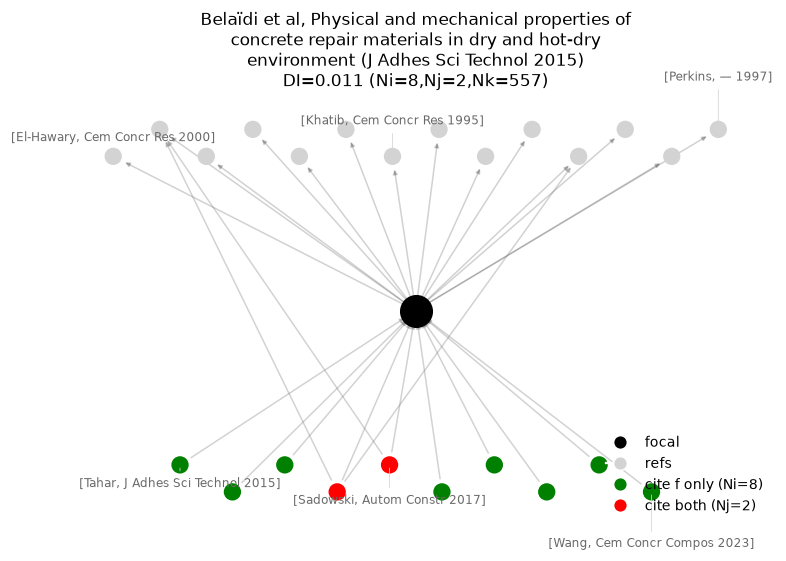

In [4]:
import urllib.request, json, textwrap
from iso4 import abbreviate
from matplotlib.lines import Line2D

# --- OpenAlex から書誌情報を引くヘルパー（図のラベル用。DI計算そのものには不要）---
_cache = {}
def meta(wid):  # 論文ID → (筆頭著者の姓, 略誌名, 出版年, タイトル)
    if wid not in _cache:
        try:
            d = json.load(urllib.request.urlopen(
                f'https://api.openalex.org/works/W{wid}?mailto=asatani@gmail.com'
                '&select=title,publication_year,authorships,primary_location', timeout=15))
            a = (d.get('authorships') or [{}])[0].get('author', {}).get('display_name', '?').split()[-1]  # 筆頭著者の姓
            j = ((d.get('primary_location') or {}).get('source') or {}).get('display_name') or ''         # 掲載誌名
            _cache[wid] = (a, abbreviate(j, periods=False) if j else '—', d.get('publication_year') or '', d.get('title') or '')
        except Exception:
            _cache[wid] = (f'W{wid}', '', '', '')
    return _cache[wid]
label = lambda w: '[{}, {} {}]'.format(*meta(w)[:3])

# --- 注目論文 f を1本選び、後続論文を3群(Ni/Nj/Nk)に分ける ---
num_cited = citations_gb.source.dropna().apply(len)   # 各論文の被引用数（citer=引用してくる論文の本数）
# 図が見やすいよう「ちょうど10本に引用され」かつ works_df に含まれる論文から1本ランダムに選ぶ
example_id = random.choice(list(num_cited[num_cited == 10].index.intersection(works_df.index)))
refs   = set(citations_df.loc[citations_df.source == example_id, 'target'])   # f の参考文献
citers = set(citations_df.loc[citations_df.target == example_id, 'source'])   # f を引用した後続論文
s      = set(citations_df.loc[citations_df.target.isin(refs), 'source'])      # f の参考文献を引用した論文
nb, nf, nr = citers & s, citers - s, s - citers - refs        # 両方(Nj) / fのみ(Ni) / 参考文献のみ(Nk)
DI = (len(nf) - len(nb)) / max(len(nf | nb | nr), 1)          # DI = (Ni - Nj) / (Ni + Nj + Nk)

# グラフ構築：f→参考文献, citer→f, 「両方」ノード→参考文献 のエッジを張る
G = nx.DiGraph()
G.add_edges_from((example_id, r) for r in refs)
G.add_edges_from((u, example_id) for u in nf | nb)
rc = citations_df[citations_df.target.isin(refs) & citations_df.source.isin(nb)]
G.add_edges_from(rc[['source', 'target']].itertuples(index=False, name=None))

# レイアウト：f=中央 / 参考文献=上段 / 引用=下段。千鳥配置。件数(10〜100)でノード径と図幅を自動調整
mx = max(len(refs), len(nf | nb), 1)
node_sz, fig_w = np.interp(mx, [10, 100], [110, 32]), np.interp(mx, [10, 100], [7, 15])
def row(ns, y, dy):   # ノード集合を横一列（+奇数番目は少しずらす千鳥）に並べる座標を返す
    ns, sp = sorted(ns), max(1.2, 0.11 * len(ns))
    xs = np.linspace(-sp, sp, len(ns)) if len(ns) > 1 else [0.]
    return {n: (x, y + dy * (i % 2)) for i, (n, x) in enumerate(zip(ns, xs))}
pos = {example_id: (0, 0), **row(refs, .8, .14), **row(nf | nb, -.8, -.14)}
col = {n: 'red' if n in nb else 'green' if n in nf else 'lightgray' for n in G}; col[example_id] = 'black'

fig, ax = plt.subplots(figsize=(fig_w, 5.2))
nx.draw_networkx_edges(G, pos, [(example_id, r) for r in refs], alpha=.18, arrowsize=6, ax=ax)   # f→参考文献
nx.draw_networkx_edges(G, pos, [e for e in G.edges if e[0] != example_id], edge_color='gray', alpha=.35, arrowsize=6, ax=ax)  # 引用エッジ
nx.draw_networkx_nodes(G, pos, node_color=[col[n] for n in G], node_size=node_sz, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=[example_id], node_color='black', node_size=node_sz * 4, ax=ax)  # f を大きく強調

# 各段から数件だけ階段状に注釈（引き出し線つき）
def annotate(ns, va, sg):
    ns = sorted(ns)
    for k, i in enumerate(np.linspace(0, len(ns) - 1, min(3, len(ns))).round().astype(int)):
        ax.annotate(label(ns[i]), pos[ns[i]], xytext=(0, sg * (8 + 11 * k)), textcoords='offset points',
                    fontsize=8, ha='center', va=va, color='dimgray', annotation_clip=False,
                    arrowprops=dict(arrowstyle='-', color='lightgray', lw=.5))
annotate(refs, 'bottom', 1); annotate(nf | nb, 'top', -1)

dot = lambda c, l: Line2D([0], [0], marker='o', color='w', mfc=c, ms=9, label=l)
ax.legend(handles=[dot('black', 'focal'), dot('lightgray', 'refs'),
                   dot('green', f'cite f only (Ni={len(nf)})'), dot('red', f'cite both (Nj={len(nb)})')],
          loc='lower right', frameon=False, fontsize=9)

a, j, y, t = meta(example_id)
ax.set_title(textwrap.fill(f'{a} et al, {t} ({j} {y})', 55) + f'\nDI={DI:.3f} (Ni={len(nf)},Nj={len(nb)},Nk={len(nr)})', fontsize=11)
ax.margins(.04); ax.axis('off'); fig.tight_layout(); fig.savefig(f'{OUT_DIR}/06_di_network.pdf'); plt.show()

**図の読み方**：

- **黒**＝注目論文 $f$、**灰**＝$f$ の参考文献。
- **緑（$N_i$）**＝$f$ だけを引用した後続論文、**赤（$N_j$）**＝$f$ と参考文献の両方を引用した後続論文。
- 緑が多い（赤が少ない）ほど $f$ は「過去を断絶させた」＝DIが高い。赤が多いほど「過去の延長」＝DIが低い。
- タイトル下の DI と $N_i/N_j/N_k$ がこの1本の実際の値です。**実行のたびに別の論文がランダムに選ばれる**ので、値や図の形は毎回変わります。

## 2. データの分布を確認する

DIの計算に入る前に、素材となるランダム抽出論文がどんな集団かを、出版年と被引用数の分布で確認します。

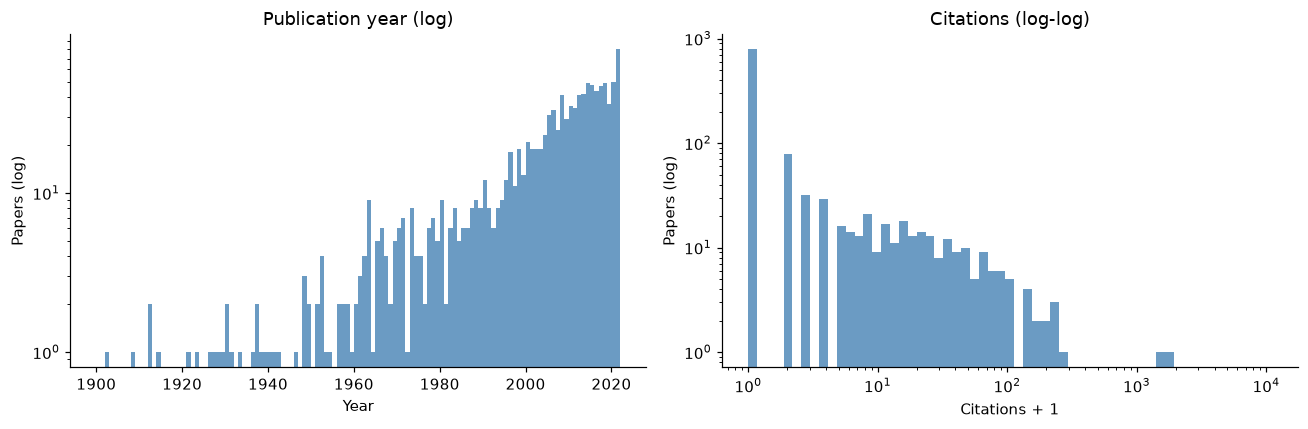

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# 左：出版年のヒストグラム（件数の縦軸は対数）
axes[0].hist(works_df['Year'], bins=range(1900, 2023), color='SteelBlue', alpha=0.8, log=True)
axes[0].set_title('Publication year (log)'); axes[0].set_xlabel('Year'); axes[0].set_ylabel('Papers (log)')
# 右：被引用数のヒストグラム（両対数。0でも対数を取れるよう +1 する）
bins = np.logspace(0, np.log10(works_df['NumberCitations'].max() + 1), 60)
axes[1].hist(works_df['NumberCitations'] + 1, bins=bins, color='SteelBlue', alpha=0.8, log=True)
axes[1].set_xscale('log'); axes[1].set_title('Citations (log-log)'); axes[1].set_xlabel('Citations + 1'); axes[1].set_ylabel('Papers (log)')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/06_distributions.pdf'); plt.show()

- **左（出版年）**：新しい年ほど論文が多い（縦軸は対数）。古い論文もわずかに含まれます。
- **右（被引用数）**：両対数で見ると右肩下がりの直線に近い＝**少数の論文が大量に引用され、大多数はほとんど引用されない**という、科学計量学で典型的なべき乗則的な分布。

## 3. Disruption Index を計算する

各注目論文について、準備セルで作った引用の対応表 `citations_gb` から「$f$ を引用した後続論文」と「$f$ の参考文献を引用した後続論文」を引き、集合演算で $N_i$・$N_j$・$N_k$ を数えてDIを出します。表引きだけなので論文ごとのAPI取得は不要です。サンプル内の全論文に対して計算を試し、参考文献や被引用情報が足りず `None` になる論文は除外して、DIを定義できた論文だけを次に進めます。

In [6]:
flatten = lambda l: [x for sub in l if sub == sub for x in sub]  # ネストしたリストを平坦化。NaN は sub!=sub で除外

def disruption(node):
    try:
        node_r = set(citations_gb.target.loc[node])                       # f の参考文献
        node_r_c = set(flatten([citations_gb.source.loc[x] for x in node_r])) - {node}  # 参考文献を引用した後続論文（f自身は除く）
        node_c = set(citations_gb.source.loc[node])                       # f を引用した後続論文
        allnodes = node_c | node_r_c                                      # f または参考文献を引用した論文の全体
        N_i = len(node_c - node_r_c)        # f のみ引用（過去と断絶）
        N_j = len(node_c & node_r_c)        # f と参考文献の両方を引用（過去の延長）
        N_k = len(node_r_c - node_c)        # 参考文献のみ引用
        return (N_i - N_j) / len(allnodes) if allnodes else None
    except (KeyError, TypeError):           # 参考文献や被引用がデータ内に無い論文は計算不能 → None
        return None

# works_df の全論文についてDIを計算し、計算できたもの（None以外）だけ残す
scores = pd.Series({eid: disruption(eid) for eid in works_df.index}, name='disruption').dropna()
print('DI computed for', len(scores), 'papers')
display(scores.describe())

DI computed for 269 papers


count    269.000000
mean       0.014133
std        0.138663
min       -1.000000
25%       -0.001692
50%       -0.000059
75%        0.001835
max        1.000000
Name: disruption, dtype: float64

`describe()` の読みどころ：

- 平均・中央値ともほぼ **0**。ほとんどの論文はDIが0付近＝「並の発展的な研究」。
- 最小 **−1**・最大 **+1** まで裾を引く：ごく一部に強く disruptive／developmental な論文がある。
- 計算できたのは 1,172本中 **269本**だけ。残りは「参考文献」または「被引用」がデータ内に無くDIを定義できないためスキップされました（`disruption()` が `None` を返した分）。

次に、この269本のDIがどう散らばっているかを図で見ます。

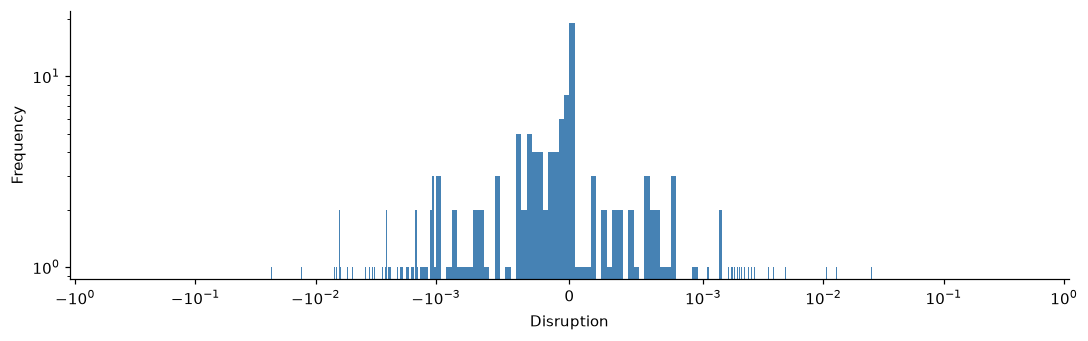

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.hist(scores, bins=50000, color='SteelBlue', linewidth=0)
# symlog: 0付近は線形・外側は対数。微小なDIも0周辺の集中も同時に見えるようにする
ax.set_yscale('log'); ax.set_xscale('symlog', linthresh=0.001)
ax.set_xlabel('Disruption'); ax.set_ylabel('Frequency')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/06_di_distribution.pdf'); plt.show()

横軸は symlog（0付近は線形、外側は対数）、縦軸は対数の頻度です。**大半のバーが0のすぐ近く**に立ち、正負の両側に少数の論文が長く裾を引きます。DIは「ほとんどの論文は0付近、まれに大きく振れる」指標だと分かります。

## 4. 高DI / 低DI 論文の例を見る

計算したDIの上位（disruptive）・下位（developmental）の論文タイトルを並べ、DIの高低が実際どんな論文に対応するかを確かめます。

In [8]:
# 計算したDIを論文メタデータ（タイトル等）と結合
tbl = (scores.to_frame().join(works_df[['Title', 'Year', 'NumberCitations', 'AuthorCount']]))
print('=== 高DI（disruptive）===')
display(tbl.sort_values('disruption', ascending=False).head(5))   # DI上位5本
print('=== 低DI（developmental）===')
display(tbl.sort_values('disruption').head(5))                    # DI下位5本

=== 高DI（disruptive）===


,disruption,Title,Year,NumberCitations,AuthorCount
1982793646,1.000000,Design Procedures for Fiber Composite Box Beams,1989,7,2.0
2889199485,1.000000,ASPECTS OF TECHNOLOGICAL OBJECTS EMULATION AT ...,2018,2,2.0
2126466006,0.957852,Molecular Structure of Nucleic Acids: A Struct...,1953,11079,2.0
1004032838,0.750000,Conditions of sustainable development in the C...,2009,10,2.0
2072465425,0.397436,NOTES ON THE BIOLOGY OF THE BLACK COUCAL,1971,43,1.0


=== 低DI（developmental）===


,disruption,Title,Year,NumberCitations,AuthorCount
2127548443,-1.000000,An X-ray diffractometer using mirage diffracti...,2015,2,6.0
2013241878,-0.408429,Viral RNA-dependent DNA Polymerase: RNA-depend...,1970,1900,1.0
2088376308,-0.153846,Reply to “Insufficient Demonstration of Long-T...,2014,3,17.0
2187913747,-0.090580,Release of free fatty acids by adipose tissue ...,1963,139,4.0
2015792769,-0.065421,Hiccups associated with levodopa in Parkinson'...,2009,15,2.0


- **高DI（disruptive）側**：被引用が少ない論文でもDI=1.0になり得ます。後続論文が数本しかないと「$f$ だけを引用」の割合が極端になりやすいためで、DIは**被引用数が小さいと不安定**です（要注意）。一方で、Watson & Crick のDNA二重らせん（1953, 被引用1万超）のように、大量に引用されつつ高DIな真に革新的な論文も見えます。
- **低DI（developmental）側**：既存研究を精緻化・追試・反論する論文が並びます。負のDIは「$f$ も参考文献も一緒に引用され続けた」＝分野の延長線上にあることを示します。

## 5. DIの分布を大規模データで再現する（Wu論文の100万件）

§3で計算したのは1,000本規模のサンプルでした。ここでは Wu et al. の公開データ（`teamsize_impact.npy` の disruption 列、100万件）で同じ分布を描き、DIの典型的な形を確認します。

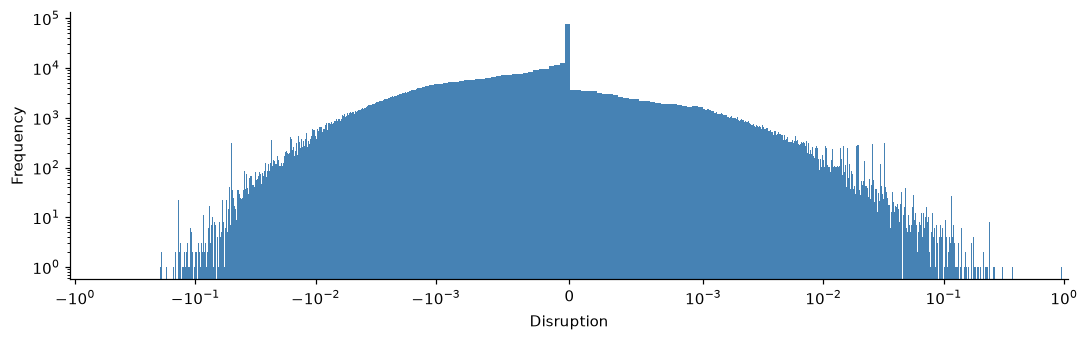

In [9]:
D = W[:, 2]  # disruption 列（100万件）
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.hist(D, bins=50000, color='SteelBlue', linewidth=0)
ax.set_yscale('log'); ax.set_xscale('symlog', linthresh=0.001)   # §3と同じ symlog 軸
ax.set_xlabel('Disruption'); ax.set_ylabel('Frequency')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/06_di_distribution_wu.pdf'); plt.show()

100万件でも形は§3と同じで、**0付近に集中し両裾に広がります**。1論文単位のDIはノイズが大きい一方、多数を平均すれば安定した比較ができる――これが次節（チームサイズ比較）の前提になります。

## 6. チームサイズ（著者数）とDIの関係

ここからは Wu et al. (2019) の100万件データで、彼らの主要結果「**小さなチームほど disruptive、大きなチームほど developmental**」を再現します。著者数1〜10人ごとに平均DIと平均被引用を取り、DIは分かりやすいよう参照分布に対する**パーセンタイル**（0〜100）で表示します。灰色帯はブートストラップ95%信頼区間です。

In [10]:
teamsize, impact, disrupt = W[:, 0], W[:, 1], W[:, 2]   # 100万件の [チームサイズ, 被引用, DI] 列
imp_by_ts, dis_by_ts = defaultdict(list), defaultdict(list)
for ts, imp, ds in zip(teamsize, impact, disrupt):     # チームサイズ1〜10人ごとに被引用・DIを集める
    if 1 <= ts <= 10:
        imp_by_ts[ts].append(imp); dis_by_ts[ts].append(ds)

ref_dist = random.sample(list(disrupt), 50000)  # DIをパーセンタイル化するための参照分布（全体から5万件サンプル）

def boot_ci(d, n=50):   # チームサイズごとに、平均のブートストラップ95%信頼区間を返す
    out = []
    for ts in range(1, 11):
        a = np.array(d[ts]); m = len(a)
        means = [np.mean(np.random.choice(a, m)) for _ in range(n)]   # 復元抽出でサイズmの平均をn回作る
        out.append([np.percentile(means, 2.5), np.percentile(means, 97.5)])
    return np.array(out).T

xs = np.arange(1, 11)
y_dis = [np.mean(dis_by_ts[t]) for t in xs]   # 各チームサイズの平均DI
y_imp = [np.mean(imp_by_ts[t]) for t in xs]   # 各チームサイズの平均被引用
dis_a, dis_b = boot_ci(dis_by_ts)
imp_a, imp_b = boot_ci(imp_by_ts)
# DIの生値は小さく直感的でないので、参照分布に対するパーセンタイルに変換
pct = lambda v: [stats.percentileofscore(ref_dist, x) for x in v]
y_dis, dis_a, dis_b = pct(y_dis), pct(dis_a), pct(dis_b)

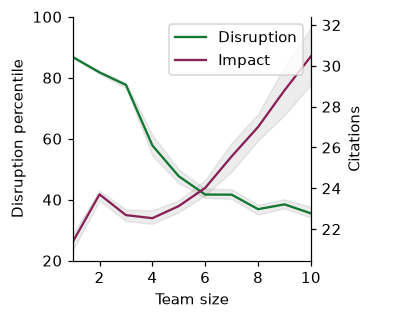

In [11]:
fig = plt.figure(figsize=(3.5, 3), facecolor='white')
host = host_subplot(111); par = host.twinx()   # 左右2軸：左=DIパーセンタイル, 右=被引用
host.plot(xs, y_dis, color='#117733', label='Disruption')
par.plot(xs, y_imp, color='#882255', label='Impact')
host.fill_between(xs, dis_a, dis_b, color='gray', alpha=0.15)   # DIの95%信頼区間
par.fill_between(xs, imp_a, imp_b, color='gray', alpha=0.15)    # 被引用の95%信頼区間
host.set_xlim(1, 10); host.set_ylim(20, 100)
host.set_xlabel('Team size'); host.set_ylabel('Disruption percentile'); par.set_ylabel('Citations')
host.legend(loc='upper right')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/06_teamsize_disruption.pdf'); plt.show()

- 緑（DIのパーセンタイル）は**チームサイズが大きくなるほど下がり**、赤（被引用数）は**上がります**。
- つまり Wu et al. (2019) の主要結論「**小さいチームほど disruptive（革新を起こしやすい）、大きいチームほど developmental だが引用は集めやすい**」が再現できました。灰色帯はブートストラップ95%信頼区間で、この傾向が偶然のばらつきでないことを示します。

## 7. 被引用数で分割したチームサイズ×DI

「小さいチームほど disruptive」は、単に小さいチームの論文が引用されにくいだけでは？　という疑問に答えるため、被引用数（impact）のパーセンタイル帯ごとに分けて、チームサイズとDIの関係を見ます。

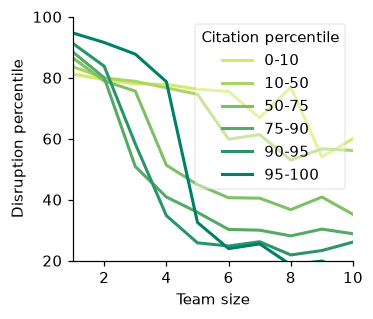

In [12]:
# 被引用数のパーセンタイル帯（下限, 上限, ラベル）
levels = [(0, 1, '0-10'), (1, 10, '10-50'), (10, 24, '50-75'), (24, 52, '75-90'), (52, 84, '90-95'), (84, 1e9, '95-100')]
dis_imp = {lab: defaultdict(list) for *_, lab in levels}
for ts, imp, ds in zip(teamsize, impact, disrupt):   # (チームサイズ, 被引用帯)ごとにDIを振り分け
    if 1 <= ts <= 10 and imp > 0:
        for lo, hi, lab in levels:
            if lo <= imp < hi if lab != '0-10' else imp <= 1:
                dis_imp[lab][ts].append(ds); break

fig, ax = plt.subplots(figsize=(3.5, 3))
cmap = plt.get_cmap('summer_r', len(levels) + 1)
for k, (*_, lab) in enumerate(levels, 1):   # 被引用帯ごとに1本の折れ線を描く
    pts = sorted((t, stats.percentileofscore(ref_dist, np.mean(v))) for t, v in dis_imp[lab].items())
    if pts:
        x, y = np.array(pts).T
        ax.plot(x, y, color=cmap(k), linewidth=2, label=lab)
ax.set_xlim(1, 10); ax.set_ylim(20, 100)
ax.set_xlabel('Team size'); ax.set_ylabel('Disruption percentile')
ax.legend(title='Citation percentile', loc='upper right', framealpha=0.4)
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/06_teamsize_by_citation.pdf'); plt.show()

被引用数の帯（0-10% 〜 95-100%）ごとに線を分けても、**どの帯でも右肩下がり**＝小さいチームほどDIが高い傾向は保たれます。「チームサイズとDIの関係は、単に引用の多寡で説明されるものではない」ことを示唆します。

## まとめ・留意点

- **DIの考え方**：後続論文が「注目論文だけを引用する（$N_i$）」か「注目論文と参考文献の両方を引用する（$N_j$）」かの差で、革新性（過去との断絶）を測る指標。
- 事前計算済みの引用エッジリストを使い、per-paper API なしでDIを**全件**計算し、高DI/低DI例・DI分布・チームサイズとの関係（Wu et al. 2019）を再現しました。
- **使うときの注意**：1論文単位のDIは被引用が少ないと不安定になりやすい。時系列比較にはとくに注意が必要で（Leibel & Bornmann 2024）、データ被覆・引用窓・分野によって値が変わります。目的に照らして慎重に使ってください。

## 付録：supplementary データの作り方（サンプル）

`random_works.parquet` と `citations.parquet` を OpenAlex から作る最小例です。DIの計算には「注目論文の参考文献」だけでなく「**参考文献を引用する後続論文**」も必要なので、(1) 母集団の取得、(2) 各論文を引用する後続論文の取得、の2段構えになります。**(2) は論文ごとにAPIを叩くため重い**ので、既定では実行しません（`BUILD_SUPPLEMENTARY = True` で有効化）。

`teamsize_impact.npy` は Wu et al. (2019) の公開データ由来で、OpenAlexからは作っていません。

In [13]:
BUILD_SUPPLEMENTARY = False  # True にすると OpenAlex から data/supplementary/ を再構築する（(2)は重い。既定はFalse）

if BUILD_SUPPLEMENTARY:
    import requests
    os.makedirs('data/supplementary', exist_ok=True)
    MAILTO = 'asatani@gmail.com'
    TOPIC  = {'bacteria': 'T11048', 'qc': 'T10020'}[NAME]   # 母集団のトピック（NAMEに追従）
    sid = lambda wid: int(wid.rsplit('/', 1)[-1].lstrip('W'))   # 'https://openalex.org/W123' -> 123

    def fetch(filter, select, max_records=20000):
        params = {'filter': filter, 'select': select, 'per-page': 200,
                  'cursor': '*', 'mailto': MAILTO}
        out = []
        while len(out) < max_records:
            r = requests.get('https://api.openalex.org/works', params=params, timeout=60).json()
            out += r['results']
            cur = r['meta'].get('next_cursor')
            if not cur or not r['results']:
                break
            params['cursor'] = cur
        return out[:max_records]

    # (1) 母集団の論文：被引用数・著者数・参考文献リスト付きで取得
    works = fetch(f'primary_topic.id:{TOPIC},to_publication_date:2024-12-31',
                  'id,title,publication_year,cited_by_count,authorships,referenced_works')
    rows, edges = [], []
    for w in works:
        f = sid(w['id'])
        rows.append({'PublicationId': f, 'Year': w['publication_year'],
                     'NumberCitations': w['cited_by_count'],
                     'AuthorCount': len(w.get('authorships') or []),
                     'Title': w.get('title')})
        for r in (w.get('referenced_works') or []):     # f が r を引用 → source=f, target=r
            edges.append((f, sid(r)))
    works_df = pd.DataFrame(rows).set_index('PublicationId')

    # (2) 各論文を引用する後続論文（cites:W<id>）。その後続論文の参考文献もエッジに加えると、
    #     「f と参考文献の両方を引用する論文（N_j）」を数えられる。論文ごとにAPIを叩くので重い。
    for f in works_df.index:
        for c in fetch(f'cites:W{f}', 'id,referenced_works', max_records=500):
            s = sid(c['id'])
            for r in (c.get('referenced_works') or []):
                edges.append((s, sid(r)))

    citations_df = pd.DataFrame(edges, columns=['source', 'target']).drop_duplicates()
    works_df.to_parquet('data/supplementary/random_works.parquet')
    citations_df.to_parquet('data/supplementary/citations.parquet')
    print('saved:', len(works_df), 'works /', len(citations_df), 'edges')